# Activity: Model Evaluation & Hyperparameter Tuning 

#### Overview
In this comprehensive session, we delve into the intricate world of machine learning, focusing on essential techniques for model evaluation and hyperparameter tuning. We will apply these methods to the Titanic dataset, exploring a variety of models including logistic regression, decision trees, and advanced ensemble methods.

#### What We Will Do:

- **Dataset Overview**: Review and familiarize ourselves with the Titanic dataset, emphasizing its features and preprocessing.
- **Model Implementation**: Explore logistic regression, decision trees, and ensemble methods, understanding their distinct characteristics and predictive capabilities.
- **Model Evaluation**: Employ cross-validation to gauge each model's performance, focusing on accuracy, precision, recall, and F1 score.
- **Hyperparameter Tuning**: Perform systematic tuning for the Random Forest model, comparing its effectiveness against default settings.
- **Performance Analysis**: Analyze and contrast the efficiency of ensemble methods with simpler models.
- **Reflective Discussion**: Engage in thoughtful discussions about the challenges in model evaluation and tuning, and the application of these techniques to other datasets.

#### Outcome
This session aims to equip us with a solid understanding of model evaluation and hyperparameter tuning, enhancing our ability to judiciously choose and apply machine learning models for diverse predictive tasks.

## 1. Import necessary libraries

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split # to split the data into training set and test set

from sklearn.impute import SimpleImputer # for missing values imputations

from sklearn.linear_model import LogisticRegression #  Import Logistic Regression Class
from sklearn.tree import DecisionTreeClassifier #Import Decision Tree Classifier Class
# Importing the Ensemble Leargning classifier from sklearn
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
# Importing the XGBClassifier from xgboost
from xgboost import XGBClassifier # Ensure xgboost is installed: !pip install xgboost (run this in the notebook if not installed)

# For Cross validation and Hyperparameter tuning 
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold # For statified cross validation and cross validation 
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV # For Grid Search and Random Search CV

# Evaluation metrics
from sklearn.metrics import classification_report

## 2. Data Loading and Preview

In [2]:
# Load the Titanic dataset
titanic_df = pd.read_csv('../data/titanic.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Exploratory Data Analysis

- Overview of the dataset's structure

In [3]:
# Overview of the dataset's structure
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- Basic statistical summaries of numerical features

In [6]:
# Basic statistical summaries of numerical features
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


- Identifying missing values in each feature

In [7]:
# Identifying missing values in each feature
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Survived Distribution

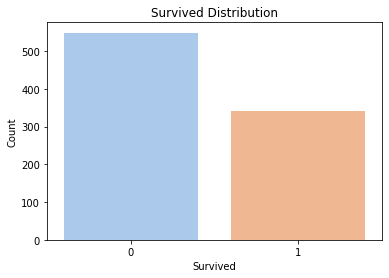

In [8]:
# Create a bar plot for Survived
plt.figure(figsize=(6, 4))
sns.countplot(data=titanic_df, x='Survived', hue = 'Survived', palette = 'pastel', legend = False)
plt.title('Survived Distribution')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

## 4. Data Preprocessing and Splitting

### Feature Selection and Engineering

In [21]:
# Selecting relevant features
selected_features = ['Age', 'Sex', 'Pclass', 'Fare', 'SibSp', 'Parch', 'Embarked']
df_features= titanic_df[selected_features].copy()
df_features.head()

,Age,Sex,Pclass,Fare,SibSp,Parch,Embarked
0,22.0,male,3,7.2500,1,0,S
1,38.0,female,1,71.2833,1,0,C
2,26.0,female,3,7.9250,0,0,S
3,35.0,female,1,53.1000,1,0,S
4,35.0,male,3,8.0500,0,0,S


### Feature Engineering

In [22]:
df_features['Family_Size'] = df_features['SibSp'] + df_features['Parch']
# Droped the columns SibSp and Parch
df_features.drop(["SibSp","Parch"], axis= 1, inplace = True)
# Review the changes
df_features.head()

,Age,Sex,Pclass,Fare,Embarked,Family_Size
0,22.0,male,3,7.2500,S,1
1,38.0,female,1,71.2833,C,1
2,26.0,female,3,7.9250,S,0
3,35.0,female,1,53.1000,S,1
4,35.0,male,3,8.0500,S,0


### Handling Categorical Variables

In [23]:
# Converting categorical variables using one-hot encoding
df_features = pd.get_dummies(df_features, columns=['Sex', 'Embarked'], drop_first = True, dtype = "int")
# Check the changes
df_features.head()

,Age,Pclass,Fare,Family_Size,Sex_male,Embarked_Q,Embarked_S
0,22.0,3,7.2500,1,1,0,1
1,38.0,1,71.2833,1,0,0,0
2,26.0,3,7.9250,0,0,0,1
3,35.0,1,53.1000,1,0,0,1
4,35.0,3,8.0500,0,1,0,1


### Data Splitting for Training and Testing

In [24]:
# Separating features and the target variable
X = df_features.copy() # Features already selected in the previous task
y = titanic_df['Survived']     # Target

# Splitting the data
# Assuming a split ratio of 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

### Data preprocessing - Handling Missing Values

In [25]:
# Imputation for numerical features
# Assuming 'Age' and 'Fare' are numerical features with missing values
numerical_imputer = SimpleImputer(strategy='median')  # Using median for skewed distributions
X_train[['Age', 'Fare']] = numerical_imputer.fit_transform(X_train[['Age', 'Fare']])
X_test[['Age', 'Fare']] = numerical_imputer.transform(X_test[['Age', 'Fare']])

# Imputation for categorical features
# Assuming 'Embarked' is a categorical feature with missing values
categorical_imputer = SimpleImputer(strategy='most_frequent')  # Using mode for categorical data
X_train[['Embarked_Q', 'Embarked_S']] = categorical_imputer.fit_transform(X_train[['Embarked_Q', 'Embarked_S']])
X_test[['Embarked_Q', 'Embarked_S']] = categorical_imputer.transform(X_test[['Embarked_Q', 'Embarked_S']])

## 5. Cross-Validation with Logistic Regression

- **Objective**: Implement and analyze cross-validation for the Logistic Regression model.

In [14]:
# Initialize the Logistic Regression model
logreg = LogisticRegression(max_iter=1000)

# Define the Stratified K-Fold cross-validation method
stratified_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation on trainign set and compute scores
logreg_scores = cross_val_score(logreg, X_train, y_train, cv=stratified_kf)

# Output the results
print(f"Logistic Regression - Accuracy scores for each fold: {logreg_scores}")
print(f"Logistic Regression - Average Accuracy: {logreg_scores.mean():.2f}")

Logistic Regression - Accuracy scores for each fold: [0.76223776 0.75524476 0.77464789 0.8028169  0.85915493]
Logistic Regression - Average Accuracy: 0.79


#### Explanation: 

- **Importing Libraries**: 
   - We import `cross_val_score` for conducting cross-validation, `StratifiedKFold` for the stratified folding strategy, and `LogisticRegression` for the classification model.
   
- **Initializing the Logistic Regression Model**: 
   - We create an instance of `LogisticRegression`. This model will be used to predict the survival on the Titanic dataset.

- **Setting Up Stratified K-Fold**: 
   - `StratifiedKFold` is initialized with 5 splits and a random shuffle, ensuring a random but consistent distribution of data across each fold. The stratification maintains the proportion of the target classes in each fold.

- **Performing Cross-Validation**: 
   - We use `cross_val_score` to perform the cross-validation. This function takes our model, feature set (`X`), target variable (`y`), and the cross-validation strategy (`stratified_kf`) as inputs.
   - It returns the accuracy for each fold, stored in `logreg_scores`.

- **Printing the Results**: 
   - The scores for each fold are printed out to give an idea of the model's performance in each split of the data.
   - The mean of these scores is calculated to provide an overall average accuracy, indicating how well the model is expected to perform in general.



#### Reflection:

- **Consistency of Model Performance**
   - The consistency of the Logistic Regression model's performance across different folds can be assessed by looking at the variance in the `logreg_scores`. Lower variance in these scores indicates that the model is stable and performs uniformly across different subsets of the data. This consistency is crucial as it suggests the model is not overly fitted to a specific part of the data and can generalize well to new, unseen data.

2. **Stratified Cross-Validation**
   - Stratified K-fold cross-validation is particularly beneficial for the Titanic dataset due to its imbalanced nature. The target variable (survival) is imbalanced, with fewer instances of one class compared to the other. Stratified cross-validation ensures that each fold maintains the same proportion of each class as the original dataset, leading to more reliable and unbiased evaluation metrics.

3. **Average Accuracy**
   - The average accuracy, computed from `logreg_scores.mean()`, provides an overall measure of how well the Logistic Regression model is expected to perform on unseen data. It’s a single metric that summarizes the model's effectiveness across all the folds of cross-validation. A higher average accuracy indicates a model that performs well across different data samples, suggesting good generalizability.

## 6. Cross-Validation with Decision Trees

- **Objective**: Apply cross-validation to assess the Decision Tree model.

To compare the performance of Decision Trees with varying `max_depth` values using both training and validation sets, we will create learning curves that show how the accuracy and other evaluation metrics change with tree depth. It's advisable to consider multiple metrics beyond just accuracy, especially for datasets with class imbalances or specific business requirements (e.g., precision might be more critical than accuracy in certain contexts).

Using `cross_validate` from scikit-learn is a more efficient approach when we need to compute multiple evaluation metrics for each cross-validation fold. It allows us to obtain various metrics in a single function call, making the code cleaner and more concise.

### Explanation

- **Metrics Selection**: We are using accuracy, precision, recall, and F1-score. This combination gives a comprehensive view of the model's performance, highlighting different aspects like the balance between precision and recall (F1-score).
- **Using `cross_validate`**: The function `cross_validate` is used to compute multiple metrics during cross-validation. Here, we calculate accuracy, precision, recall, and F1-score for each fold.

- **Loop Through Depths**: We iterate over a range of tree depths. For each depth:
   - A Decision Tree model is instantiated.
   - `cross_validate` computes the specified metrics on training and validation (test) sets.
   - Cross-validation is performed using `StratifiedKFold` to get validation metrics.

- **Recording Scores**: Training and validation scores for each metric are stored in separate lists. This data is used to plot the learning curves.

- **Plotting Learning Curves**: Four subplots are created, each representing a different metric. The curves show how each metric changes with tree depth on both training and validation sets.

- **Interpreting the Plots**: 
   - If training scores are high but validation scores are low, it indicates overfitting.
   - An ideal depth is where validation scores are high, and the gap between training and validation scores is minimal.
   - The plots for precision, recall, and F1-score provide additional insights beyond accuracy, especially useful for imbalanced datasets.

In [15]:
depths = [3, 5, 10, 15]
metrics = ['accuracy', 'precision', 'recall', 'f1']
results = {metric: {'train': [], 'validate': []} for metric in metrics}
# Initialize an empty DataFrame to store the results
results_df = pd.DataFrame(index=depths, columns=metrics)

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # Cross-validation
    stratified_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(dt, X_train, y_train, cv=stratified_kf, 
                            scoring=metrics, return_train_score=True)
    
    # Storing scores for each metric
    for metric in metrics:
        train_key = f'train_{metric}'
        test_key = f'test_{metric}'
        results[metric]['train'].append(np.mean(scores[train_key]))
        results[metric]['validate'].append(np.mean(scores[test_key]))
        # Storing average metrics in the DataFrame
        results_df.loc[depth, metric] = np.mean(scores[f'test_{metric}'])

# Print the DataFrame
print("Cross-Validation Metrics at Different Tree Depths:")
results_df

Cross-Validation Metrics at Different Tree Depths:


,accuracy,precision,recall,f1
3,0.817443,0.811966,0.688889,0.743534
5,0.785118,0.786569,0.615623,0.685941
10,0.796356,0.760121,0.692593,0.722667
15,0.779543,0.708583,0.72202,0.714032


The cross-validation metrics table for the Decision Tree model at various tree depths provides a comprehensive look at how the depth of the tree impacts its performance on the Titanic dataset:

- At a **tree depth of 3**, the model achieves the best balance across all evaluated metrics. It has the highest accuracy and F1-score, indicating a good trade-off between precision and recall. This suggests that the model is generalizing well without overfitting to the training data. The model is correctly identifying a high proportion of actual positives (precision) while also capturing a significant proportion of all possible positives (recall).

- Increasing the tree depth to **5** shows a decrease in accuracy, precision, recall, and F1-score. This suggests that adding complexity to the model (in the form of a deeper tree) does not benefit performance and may be starting to overfit, as indicated by the decline in validation performance.

- At a **tree depth of 10**, there's a slight recovery in accuracy and an increase in recall compared to a depth of 5, but precision drops. The model is becoming more sensitive to identifying positive instances but at the cost of correctly labeling them, leading to more false positives.

- At a **tree depth of 15**, the trend of decreasing precision continues, and although recall is the highest, this is a typical symptom of overfitting where the model becomes too tailored to the training data. The model is now capturing almost all positives but also misclassifying negatives as positives, as evidenced by the lower precision.

Overall, the model performs best at a tree depth of 3, where it is neither too simple nor too complex for the data it's being trained on. Beyond this depth, the increase in tree complexity does not yield better generalization on the validation set; instead, it leads to overfitting. This is reflected in the decline or inconsistency of accuracy, precision, and F1-score as the tree depth increases. Thus, for new unseen data, a tree depth of 3 is likely to produce the best predictive performance, avoiding the pitfalls of overfitting while maintaining a robust ability to predict outcomes accurately.

### Plotting learning curves for each metric

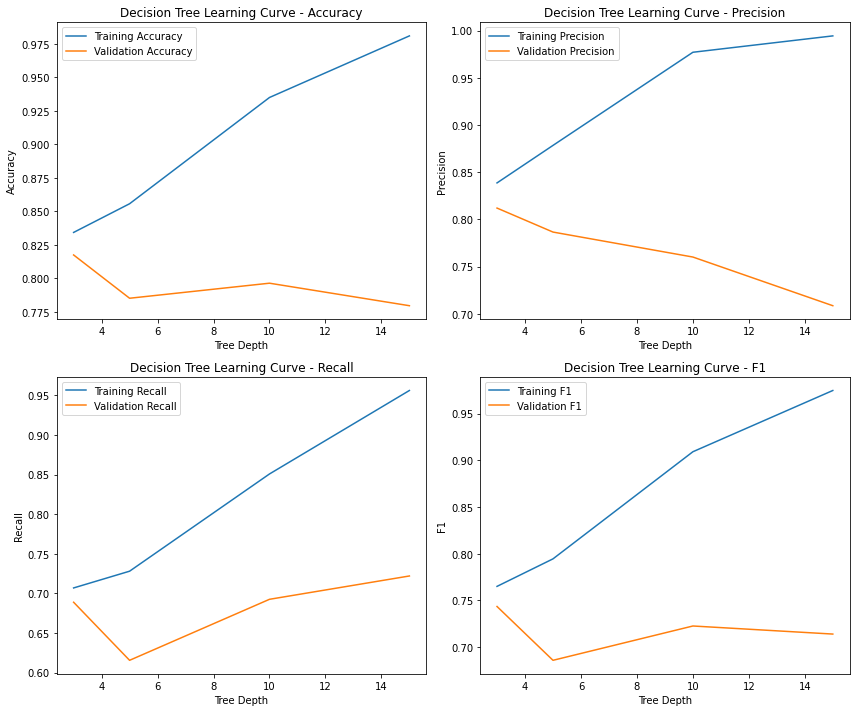

In [16]:
# Plotting learning curves for each metric
plt.figure(figsize=(12, 10))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.plot(depths, results[metric]['train'], label=f'Training {metric.capitalize()}')
    plt.plot(depths, results[metric]['validate'], label=f'Validation {metric.capitalize()}')
    plt.xlabel('Tree Depth')
    plt.ylabel(metric.capitalize())
    plt.title(f'Decision Tree Learning Curve - {metric.capitalize()}')
    plt.legend()

plt.tight_layout()
plt.show()

### Learning Curve Analysis

The learning curves for accuracy, precision, recall, and F1-score each tell us about different aspects of the Decision Tree's performance:

1. **Training Scores**: The training scores consistently increase with tree depth across all metrics. This is expected as a deeper tree can capture more details of the training data.

2. **Validation Scores**: The validation scores do not follow the same increasing trend. Instead, they peak at a tree depth of 3 for accuracy and precision and then generally decline or fluctuate. This suggests that while the tree model becomes better at classifying the training data with increased depth, it does not necessarily improve its performance on unseen data. In fact, the model begins to overfit the training data as depth increases, leading to a decrease in validation scores.

3. **Generalization**: The widening gap between training and validation scores as depth increases indicates overfitting. A model that generalizes well would have closer training and validation scores.

### Optimal Complexity

The best trade-off between bias and variance for each metric can be identified by looking for a tree depth where the validation scores are highest or where the convergence between training and validation scores is the best:

1. **Accuracy**: The highest validation accuracy is observed at a tree depth of 3. Beyond this point, the model starts to overfit, as indicated by increasing training accuracy and decreasing validation accuracy.

2. **Precision**: Similarly, the best precision occurs at a tree depth of 3, after which the validation precision drops significantly, indicating overfitting.

3. **Recall**: The recall shows an increasing trend, which suggests that the model is getting better at identifying all relevant instances. However, this increase comes at the cost of precision and F1-score, which both decrease, indicating a loss in the balance between recall and precision.

4. **F1-Score**: The F1-score combines precision and recall into a single metric, and the highest validation F1-score is again at a tree depth of 3.

### Depth Recommendation

Based on the learning curves and the table of metrics:

- **Tree Depth Recommendation**: A tree depth of 3 is recommended as it provides the highest validation accuracy and F1-score, indicating a good balance between bias and variance. At this depth, the model is sufficiently complex to learn the underlying patterns in the data but not so complex that it overfits to the noise in the training set.

In conclusion, for this Decision Tree model on the Titanic dataset, a shallower tree seems to generalize better. It is important to note that while deeper trees may perform exceptionally well on the training data, their performance on the validation data (which is a proxy for unseen data) is a better indicator of how the model will perform in practice. The optimal tree depth is one that maximizes the model's performance on unseen data while maintaining the ability to capture the underlying patterns within the data.

## 7. Hyperparameter Tuning on Random Forest

- **Objective:** Practice hyperparameter tuning on the Random Forest model to optimize its performance on the Titanic dataset.

In [28]:
# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': [None,'sqrt', 'log2'],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Set up the GridSearchCV object
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=StratifiedKFold(5), n_jobs=-1, verbose=2, error_score='raise')

# Perform the grid search and fit the model
grid_search.fit(X_train, y_train)

# Retrieve the best parameters from the grid search
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters found:  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


The grid search for hyperparameter tuning of the Random Forest model has identified that the best performing model uses a tree depth (`max_depth`) of 20, with the number of features considered at each split (`max_features`) being the square root of the total number of features. It also suggests that the best leaf size (`min_samples_leaf`) is 1, the minimum number of samples required to split a node (`min_samples_split`) is 10, and the optimal number of trees in the forest (`n_estimators`) is 100.

### Explanation

1. **Parameter Grid Setup**: We create a dictionary that specifies the range of hyperparameters we want to optimize.

2. **GridSearchCV Initialization**: A `GridSearchCV` object is initialized with the Random Forest classifier, the parameter grid, and a StratifiedKFold cross-validator. `n_jobs=-1` enables the use of all available CPU cores for parallel computation, and `verbose=2` provides detailed logs during the search.

3. **Model Fitting**: We fit the model using the training data. `GridSearchCV` will evaluate all combinations of parameters in the grid across the folds of the cross-validation.

4. **Best Parameters and Model Evaluation**: After the grid search completes, we extract the best parameters and evaluate the corresponding best Random Forest model on the test set.

5. **Comparison with Default Model**: Finally, we fit a default Random Forest classifier with standard settings and compare its performance against the tuned model using the test data.

In [32]:
# Evaluate the best model found by GridSearchCV on the test data
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
print("Model Best Parameter performance:")
print(classification_report(y_test, y_pred))

# Compare with the default model
default_rf = RandomForestClassifier(random_state=42)
default_rf.fit(X_train, y_train)
default_y_pred = default_rf.predict(X_test)
print("Default Model Performance:")
print(classification_report(y_test, default_y_pred))

Model Best Parameter performance:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       110
           1       0.73      0.71      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179

Default Model Performance:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.75      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



### Interpretation of Model Performance:
- **Precision**: The tuned model's precision for class 1 is slightly lower than the default model, indicating it was slightly less accurate in predicting the positive class.
- **Recall**: The tuned model's recall for class 1 is marginally lower than the default model, indicating it identified a slightly lower proportion of actual positives.
- **F1-Score**: The F1-score, which balances precision and recall, is marginally lower for the tuned model for class 1.
- **Accuracy**: Overall accuracy is marginally lower for the tuned model compared to the default model.


1. **Best Parameter Combination**: The best result was obtained with a tree depth of 20, square root of the number of features, a minimum leaf size of 1, minimum split size of 10, and 100 trees.
2. **Comparison to Default Model**: The tuned model does not significantly outperform the default model; it actually performs slightly worse in terms of precision, recall, and accuracy for class 1. 

This suggests that the default hyperparameters for the RandomForestClassifier were quite effective for this dataset, and the additional complexity introduced by the grid search did not yield substantial improvements. It's also possible that the hyperparameters space explored in the grid search did not include the best possible combinations, or that the model is highly sensitive to the data and minor changes in the hyperparameter settings.

## 8. Evaluating Ensemble Methods with cross validation

- **Objective:** Examine and compare the performance of various ensemble learning techniques on the Titanic dataset.

In [34]:
# Initialize models
models = {
    'AdaBoost': AdaBoostClassifier(),
    'GradientBoosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Stratified K-Fold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# DataFrame to store results
results_df = pd.DataFrame()

# Evaluate each model using cross-validation
for name, model in models.items():
    cv_results = cross_validate(model, X_train, y_train, cv=cv, 
                                scoring=['accuracy', 'precision', 'recall', 'f1'])
    
    # Store results in DataFrame
    results_df[name] = [cv_results['test_accuracy'].mean(), 
                        cv_results['test_precision'].mean(),
                        cv_results['test_recall'].mean(),
                        cv_results['test_f1'].mean()]

# Setting row names for better readability
results_df.index = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Display results
results_df

,AdaBoost,GradientBoosting,XGBoost
Accuracy,0.806195,0.844164,0.792121
Precision,0.754100,0.834044,0.739945
Recall,0.740202,0.743973,0.718182
F1 Score,0.744328,0.784688,0.725175


### Explanation

1. **Model Setup**: The AdaBoost, Gradient Boosting, and XGBoost models are initialized.

2. **Cross-Validation**: `cross_validate` is used for each model with Stratified K-Fold cross-validation. This method maintains the proportion of each class, which is important for balanced evaluation, especially on datasets like Titanic.

3. **Metrics Calculation**: Cross-validation is performed with multiple scoring metrics (accuracy, precision, recall, F1-score).

4. **Results Aggregation**: The mean of each metric across the cross-validation folds is calculated and stored in a DataFrame for easy comparison.

5. **Output**: The DataFrame, displaying the average scores for each model and each metric, is printed. This gives a clear side-by-side comparison of the ensemble methods.

Based on the provided cross-validation metrics, the performance of the ensemble methods on the Titanic dataset can be interpreted as follows:

1. **Ensemble Method Comparison**:
   - **Gradient Boosting** shows the superior performance among the three models. It has the highest accuracy and precision, and its recall and F1 score are also competitive.
   - **AdaBoost** performs reasonably well but falls behind Gradient Boosting in all metrics.
   - **XGBoost** has the lowest accuracy and precision among the three but remains competitive in recall and F1 score.

2. **Comparison with Simpler Models**:
   - Generally, ensemble methods like Gradient Boosting tend to outperform simpler models like logistic regression, especially in terms of accuracy and precision. This is due to their ability to capture complex patterns in the data.
   - However, the gain in performance must be weighed against the increased computational complexity and potential overfitting. Simpler models might be preferable in cases where interpretability and computational efficiency are more critical.

In conclusion, Gradient Boosting appears to be the most effective model for this dataset among the ensemble methods tested, likely due to its robustness in handling various data complexities. However, the choice between these models and simpler ones like logistic regression would depend on the specific requirements of the task, including the need for model interpretability, computational resources, and the nature of the dataset.

### Model Comparison - Ensemble Methods and Logistic Regression

In [36]:
# Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=1000)

# Perform cross-validation
log_reg_results = cross_validate(log_reg, X_train, y_train, cv=cv, 
                                 scoring=['accuracy', 'precision', 'recall', 'f1'])

# Add Logistic Regression results to the DataFrame
results_df['Logistic Regression'] = [
    log_reg_results['test_accuracy'].mean(), 
    log_reg_results['test_precision'].mean(),
    log_reg_results['test_recall'].mean(),
    log_reg_results['test_f1'].mean()
]

# Display updated results
print("Model Comparison (Ensemble Methods and Logistic Regression):")
results_df

Model Comparison (Ensemble Methods and Logistic Regression):


,AdaBoost,GradientBoosting,XGBoost,Logistic Regression
Accuracy,0.806195,0.844164,0.792121,0.790820
Precision,0.754100,0.834044,0.739945,0.741439
Recall,0.740202,0.743973,0.718182,0.695960
F1 Score,0.744328,0.784688,0.725175,0.716704


**Interpretation of Logistic Regression Results**:
- **Logistic Regression** shows a close performance to XGBoost in terms of accuracy and precision. However, it slightly lags in recall and F1-score.
- The model's recall is lower compared to ensemble methods, indicating it is less effective in identifying all positive instances.
- Its precision is competitive, suggesting it's relatively accurate when it predicts positive instances.

**Summary**:
- **Gradient Boosting** outperforms other models in accuracy, precision, recall, and F1-score.
- **Logistic Regression**, while simpler and more interpretable, holds up well in precision but falls behind in other metrics.
- This comparison underlines the strength of ensemble methods in complex datasets, with Gradient Boosting being particularly effective. However, Logistic Regression remains a viable, simpler alternative when interpretability and model simplicity are priorities.

## 9. Discussion and Reflection

- **Objective:** Reflect on the learning experience and insights gained from the tasks, focusing on model evaluation and hyperparameter tuning.

### Example of Answers for Task 5: Discussion and Reflection

1. **Challenges in Model Evaluation and Tuning**:
   - One significant challenge was managing the trade-off between model complexity and performance. In hyperparameter tuning, particularly with ensemble methods, we observed a delicate balance where increasing complexity sometimes led to overfitting.
   - Another challenge was computational cost, especially with GridSearchCV, which required careful consideration of the parameter grid to avoid excessively long processing times.

2. **Applying Techniques to Other Contexts**:
   - The techniques of cross-validation and hyperparameter tuning are universally applicable across various datasets. The principles of identifying overfitting, understanding bias-variance tradeoff, and methodically searching for optimal parameters are relevant regardless of the dataset.
   - However, the specific parameters and models chosen would need to be tailored to the characteristics of each new dataset, such as its size, feature types, and the nature of the problem (classification or regression).

This reflection consolidates our understanding that while the fundamental techniques of machine learning are broadly applicable, their specific application requires careful consideration of the dataset and problem context.